<a href="https://colab.research.google.com/github/mjksill/CCP5SummerSchool/blob/master/notebooks/CCP5_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Questions from CCP5 workshop




## fitting data

### Generate Random Data

First, let's create a dataset where `y` is a polynomial function of `x` with some added noise.

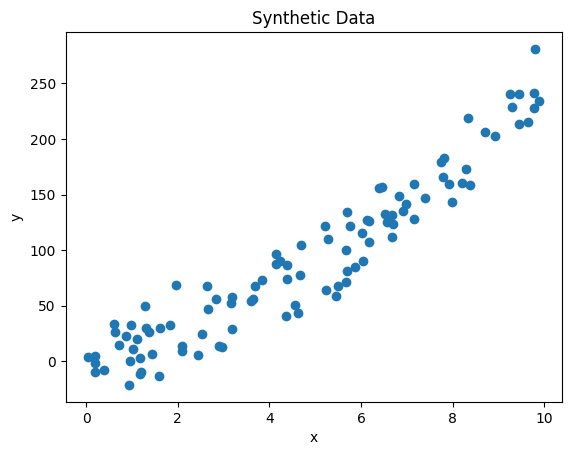

In [ ]:
# import library
import numpy as np

# Generate synthetic data
np.random.seed(0)
x = np.random.rand(100, 1) * 10  # 100 random numbers between 0 and 10
y = 2 * x**2 + 5 * x + 3 + np.random.randn(100, 1) * 20  # A quadratic function with noise

# Sort x for better plotting
x_sorted = np.sort(x, axis=0)
y_sorted = y[np.argsort(x, axis=0).flatten()]

import matplotlib.pyplot as plt

plt.plot(x_sorted, y_sorted, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data')
plt.show()

### Perform regression

The data can be let's achieve the same polynomial regression using `scipy.optimize.curve_fit`. This function allows you to fit data to an arbitrary user-defined function. For a quadratic polynomial, the function will be of the form $f(x) = ax^2 + bx + c$.

In [ ]:
from scipy.optimize import curve_fit

# Define the polynomial function (quadratic in this case)
def polynomial_function(x, a, b, c):
    return a * x**2 + b * x + c

# Perform the curve fitting
# curve_fit returns the optimal parameters (popt) and the covariance matrix (pcov)
popt, pcov = curve_fit(polynomial_function, x.flatten(), y.flatten())

# Extract the fitted coefficients
a_fit, b_fit, c_fit = popt
print(f"Fitted coefficients (a, b, c): {a_fit:.2f}, {b_fit:.2f}, {c_fit:.2f}")

# Generate predictions using the fitted function
y_pred_scipy = polynomial_function(x_new.flatten(), a_fit, b_fit, c_fit)


Fitted coefficients (a, b, c): 1.64, 8.36, 2.03


### Visualize results

Let's plot the original data, the true polynomial, and the curve fitted by SciPy to see how it compares.

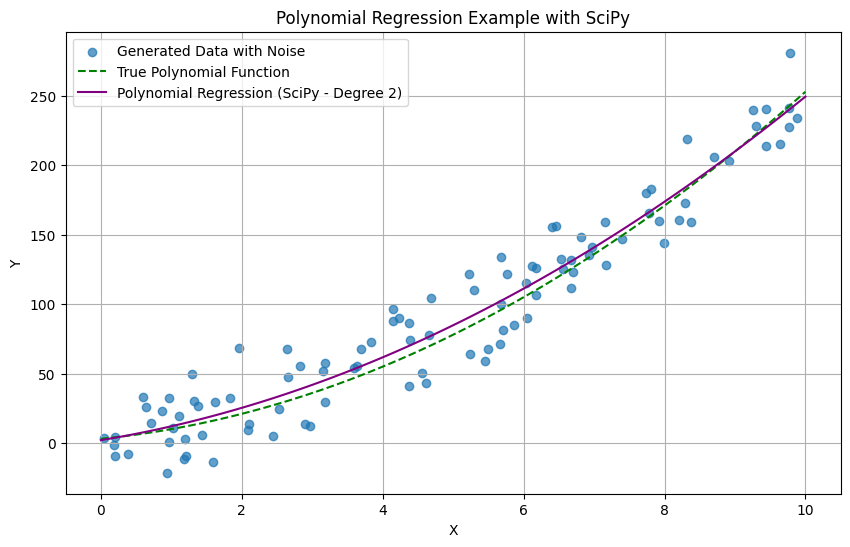

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Generated Data with Noise', alpha=0.7)

# Plot the true underlying polynomial
y_true = 2 * x_new**2 + 5 * x_new + 3
plt.plot(x_new, y_true, color='green', linestyle='--', label='True Polynomial Function')

# Plot the fitted polynomial regression curve from scipy
plt.plot(x_new, y_pred_scipy, color='purple', label=f'Polynomial Regression (SciPy - Degree {degree})')

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

## Spline interpolation

If we have a smooth set of data, such as from a well defined function sampled at various discrete points, we can estimate the value of the function




In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline

# Define your 1D data points (x must be strictly increasing)
x = np.linspace(0, 3, 11)
y = x**2

# Create the interpolating spline
spl = UnivariateSpline(x, y)

# Calculate definite integral from a to b
result = spl.integral(0, 3)
print(result) # Output: 9.0 (since ∫ x^2 dx = x^3 / 3 evaluated from 0 to 3)


9.0
